Feature Engineering

Key Columns:
Country, City: Location details.
AQI Value, AQI Category: Overall Air Quality Index (AQI) and its category.
CO, Ozone, NO2, PM2.5 AQI Value/Category: AQI values and categories for specific pollutants.
lat, lng: Latitude and longitude

Feature Engineering Plan:
Handle Missing Values:

Impute missing values in the Country column.
Create New Features:

Location Features: Combine lat and lng into a single feature or calculate distances.
Pollutant Ratios: Create ratios like CO AQI Value / PM2.5 AQI Value.
Overall AQI Insights:
Calculate the maximum AQI value among pollutants.
Count how many pollutants are in the "Good" category for each row.
Encode Categorical Features:

Convert AQI Category and pollutant categories into numerical formats.
Outlier Detection:

Identify and handle unusually high pollutant values.
Scaling/Normalization:

Normalize numerical columns for downstream modeling.

Stastical Summary

In [2]:
import pandas as pd

# Load the dataset
file_path = 'Data\Real-Data\AQI and Lat Long of Countries.csv'  # Replace with your file path
data = pd.read_csv(file_path)

# Step 1: Handle Missing Values
data['Country'].fillna('Unknown', inplace=True)

# Step 2: Create New Features
# Combine lat and lng into a tuple for location-based analysis
data['Coordinates'] = list(zip(data['lat'], data['lng']))

# Calculate maximum AQI value among pollutants for each row
data['Max Pollutant AQI'] = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].max(axis=1)

# Count pollutants in the "Good" category
pollutant_categories = ['CO AQI Category', 'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category']
data['Good Pollutants Count'] = data[pollutant_categories].apply(lambda row: row.str.contains('Good').sum(), axis=1)

# Step 3: Encode Categorical Features
# Map AQI categories to numerical values (e.g., Good -> 1, Moderate -> 2, etc.)
category_mapping = {'Good': 1, 'Moderate': 2, 'Unhealthy': 3, 'Very Unhealthy': 4, 'Hazardous': 5}
for col in pollutant_categories + ['AQI Category']:
    data[f'{col} Encoded'] = data[col].map(category_mapping)

# Step 4: Outlier Detection (Identifying high AQI values)
# Add a flag for rows where any pollutant AQI value exceeds a threshold (e.g., 150)
data['High AQI Flag'] = data[['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].max(axis=1) > 150

# Display the processed data
print(data.head())


C:\Users\Hitarth\AppData\Local\Temp\ipykernel_932\893399135.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Country'].fillna('Unknown', inplace=True)


              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  ...  Cluster           Coordinates  Max Pollutant AQI  \
0  

In [3]:
import numpy as np

# Step 5: Distance Calculation (e.g., distance from the equator)
data['Distance from Equator'] = data['lat'].apply(lambda x: abs(x))

# Step 6: Pollutant Contribution
pollutants = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
for pollutant in pollutants:
    data[f'{pollutant} Contribution (%)'] = (data[pollutant] / data['AQI Value']) * 100

# Step 7: Environmental Index (average pollutant AQI values)
data['Environmental Index'] = data[pollutants].mean(axis=1)

# Step 8: Severity Score
encoded_columns = [f'{col} Encoded' for col in pollutant_categories]
data['Severity Score'] = data[encoded_columns].sum(axis=1)

# Step 9: Interaction Features (e.g., product of CO and Ozone AQI values)
data['CO_Ozone Interaction'] = data['CO AQI Value'] * data['Ozone AQI Value']

# Step 10: Aggregations by Country
country_agg = data.groupby('Country').agg({
    'AQI Value': ['mean', 'max', 'std'],
    'Good Pollutants Count': ['mean', 'sum'],
    'Severity Score': 'mean'
}).reset_index()
country_agg.columns = ['Country', 'AQI Mean', 'AQI Max', 'AQI Std', 
                       'Avg Good Pollutants', 'Total Good Pollutants', 'Avg Severity Score']

# Step 11: Correlation Analysis
correlation_matrix = data[pollutants + ['AQI Value', 'Environmental Index']].corr()

# Display results
print(data.head())
print(country_agg.head())
print(correlation_matrix)


              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  ...  AQI Category Encoded High AQI Flag  \
0             Goo

Outlier detection Visualization

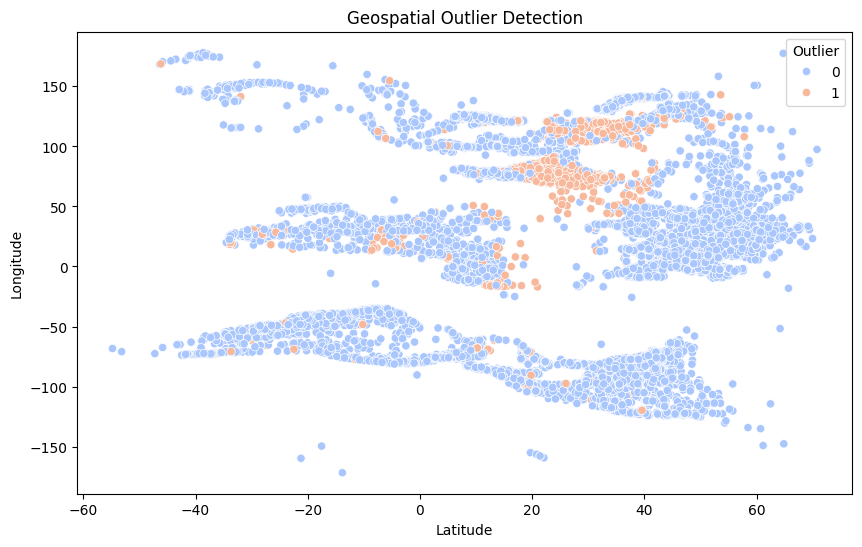

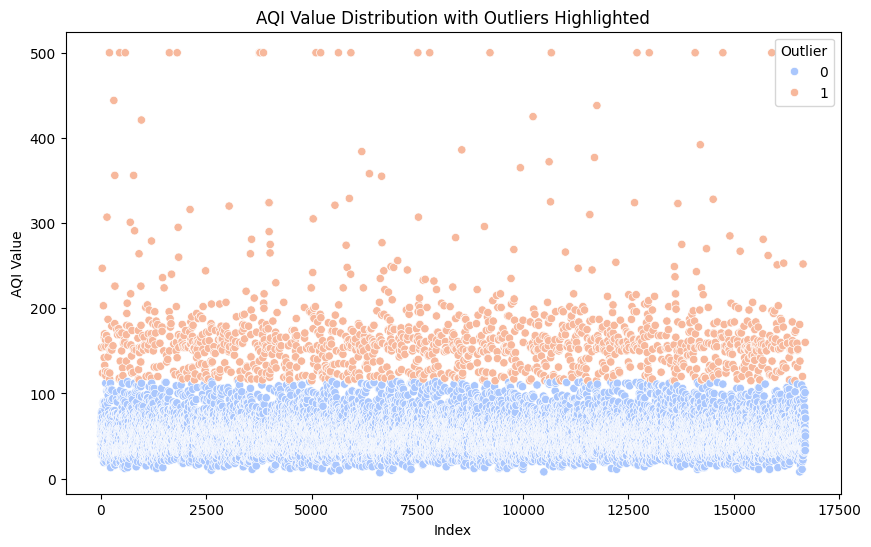

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Detect outliers in 'AQI Value' using the IQR method
Q1 = data['AQI Value'].quantile(0.25)
Q3 = data['AQI Value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create an 'Outlier' column
data['Outlier'] = ((data['AQI Value'] < lower_bound) | (data['AQI Value'] > upper_bound)).astype(int)

# Highlighting outliers on a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='lat', y='lng', hue='Outlier', palette='coolwarm')
plt.title('Geospatial Outlier Detection')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend(title="Outlier", loc='upper right')
plt.show()

# Scatter plot of AQI Value distribution, highlighting outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x=range(len(data)), y='AQI Value', hue='Outlier', palette='coolwarm')
plt.title('AQI Value Distribution with Outliers Highlighted')
plt.xlabel('Index')
plt.ylabel('AQI Value')
plt.legend(title="Outlier", loc='upper right')
plt.show()


Data Imputation Visualization

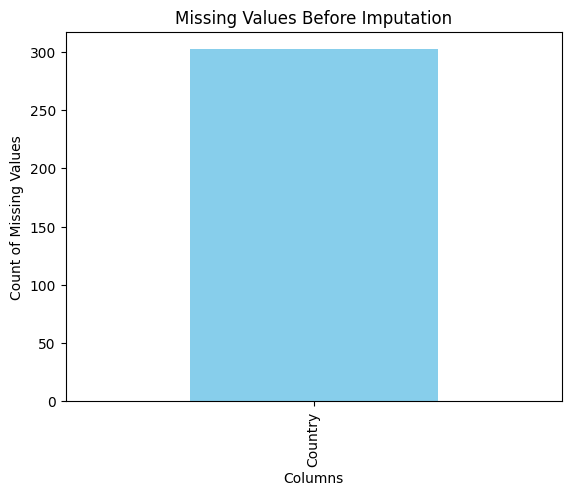

C:\Users\Hitarth\AppData\Local\Temp\ipykernel_7684\823532624.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Country'].fillna('Unknown', inplace=True)
C:\Users\Hitarth\AppData\Local\Temp\ipykernel_7684\823532624.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

Data imputation complete. File saved to: D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv


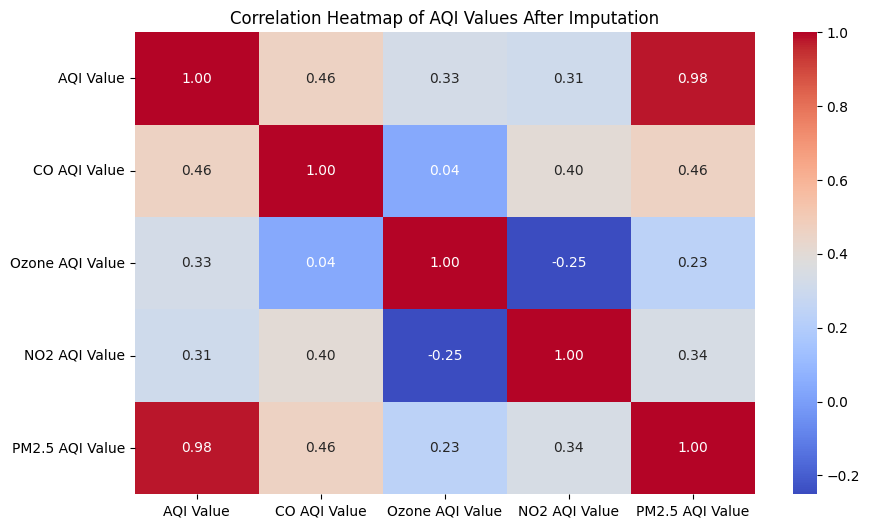

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Bar plot of missing values before imputation
missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    missing_counts.plot(kind='bar', color='skyblue')
    plt.title('Missing Values Before Imputation')
    plt.xlabel('Columns')
    plt.ylabel('Count of Missing Values')
    plt.show()
else:
    print("No missing values found before imputation.")

# Fill missing values in 'Country' with 'Unknown'
data['Country'].fillna('Unknown', inplace=True)

# Fill missing numerical columns with the median
numerical_columns = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
for col in numerical_columns:
    data[col].fillna(data[col].median(), inplace=True)

# Save the updated dataset
imputation_file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data.to_csv(imputation_file_path, index=False)

print(f"Data imputation complete. File saved to: {imputation_file_path}")

# Heatmap of numerical columns after imputation
plt.figure(figsize=(10, 6))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of AQI Values After Imputation')
plt.show()


Feature Scaling and Normalization

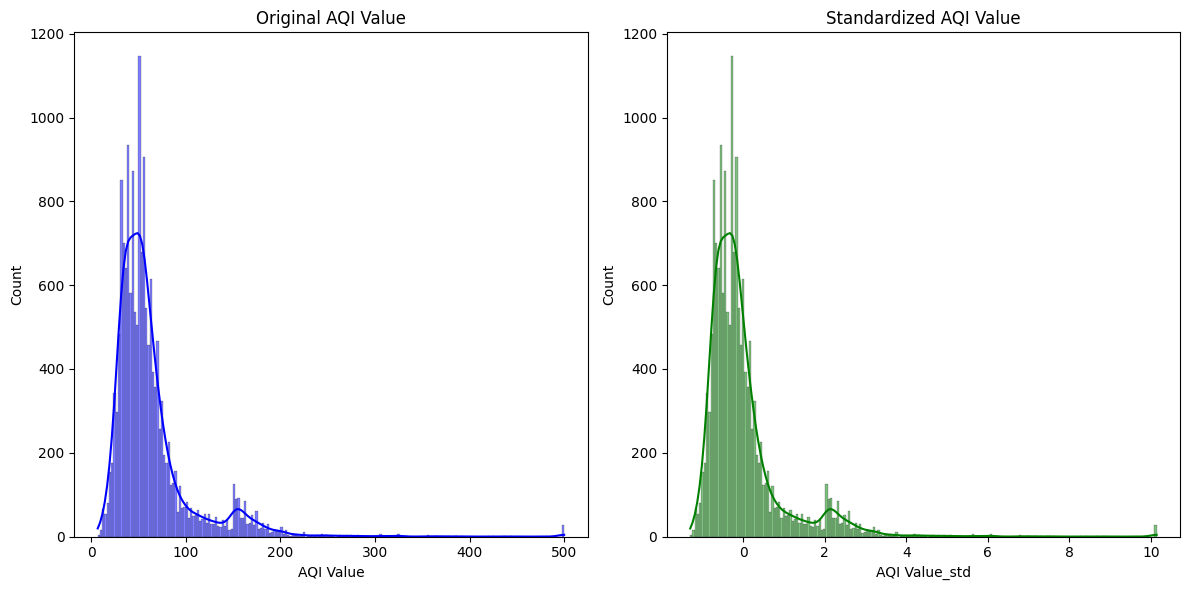

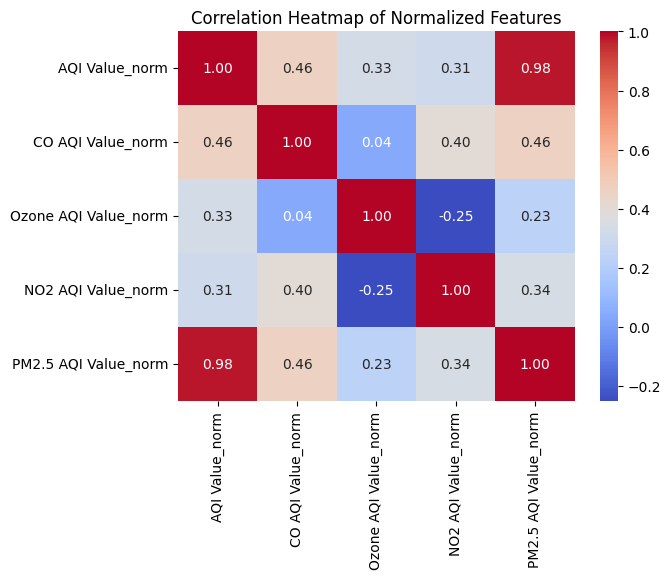

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'D:\Air-Quality-Prediction\Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Select numerical columns to scale
numerical_columns = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

# Standard Scaling
scaler = StandardScaler()
data[[f"{col}_std" for col in numerical_columns]] = scaler.fit_transform(data[numerical_columns])

# Min-Max Normalization
minmax_scaler = MinMaxScaler()
data[[f"{col}_norm" for col in numerical_columns]] = minmax_scaler.fit_transform(data[numerical_columns])

# Distribution before and after scaling for 'AQI Value'
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(data['AQI Value'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original AQI Value')

sns.histplot(data['AQI Value_std'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Standardized AQI Value')

plt.tight_layout()
plt.show()

# Heatmap of normalized features
normalized_cols = [f"{col}_norm" for col in numerical_columns]
sns.heatmap(data[normalized_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Normalized Features')
plt.show()



Encoading Categorical Feature Visualization

C:\Users\Hitarth\AppData\Local\Temp\ipykernel_7684\2279241129.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='AQI Category', palette='viridis')


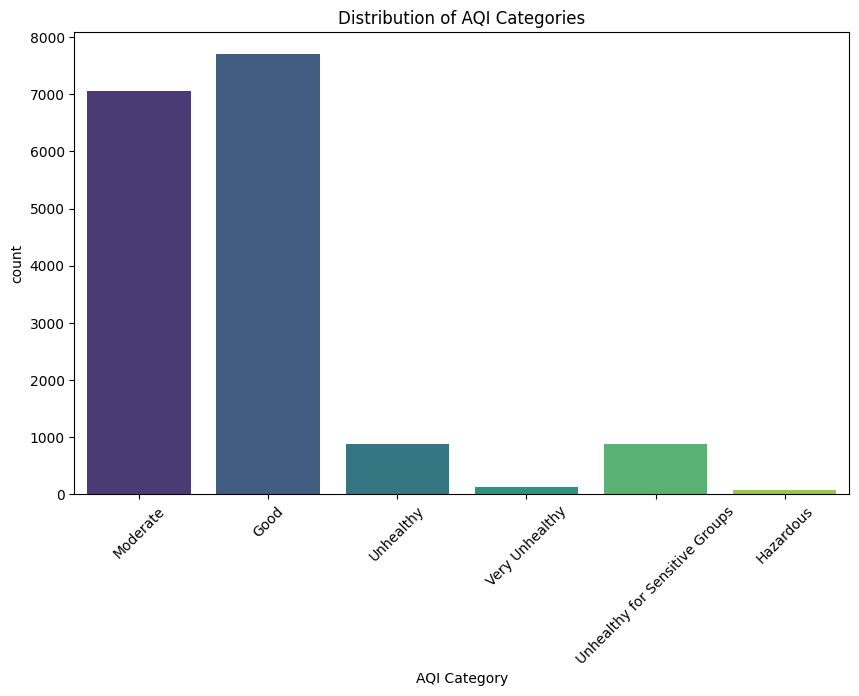

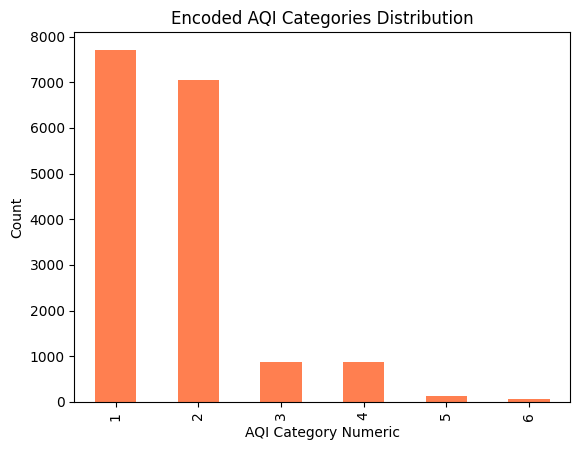

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the dataset
file_path = 'Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Encode categorical AQI Categories
category_mapping = {
    'Good': 1,
    'Moderate': 2,
    'Unhealthy for Sensitive Groups': 3,
    'Unhealthy': 4,
    'Very Unhealthy': 5,
    'Hazardous': 6
}
data['AQI Category Numeric'] = data['AQI Category'].map(category_mapping)



# Count plot of AQI Categories before encoding
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='AQI Category', palette='viridis')
plt.title('Distribution of AQI Categories')
plt.xticks(rotation=45)
plt.show()

# Bar plot of numeric encoded AQI Categories
encoded_counts = data['AQI Category Numeric'].value_counts().sort_index()
encoded_counts.plot(kind='bar', color='coral')
plt.title('Encoded AQI Categories Distribution')
plt.xlabel('AQI Category Numeric')
plt.ylabel('Count')
plt.show()

C:\Users\Hitarth\AppData\Local\Temp\ipykernel_7684\2122994243.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_aggregates, x='Country', y='Avg AQI', palette='coolwarm')


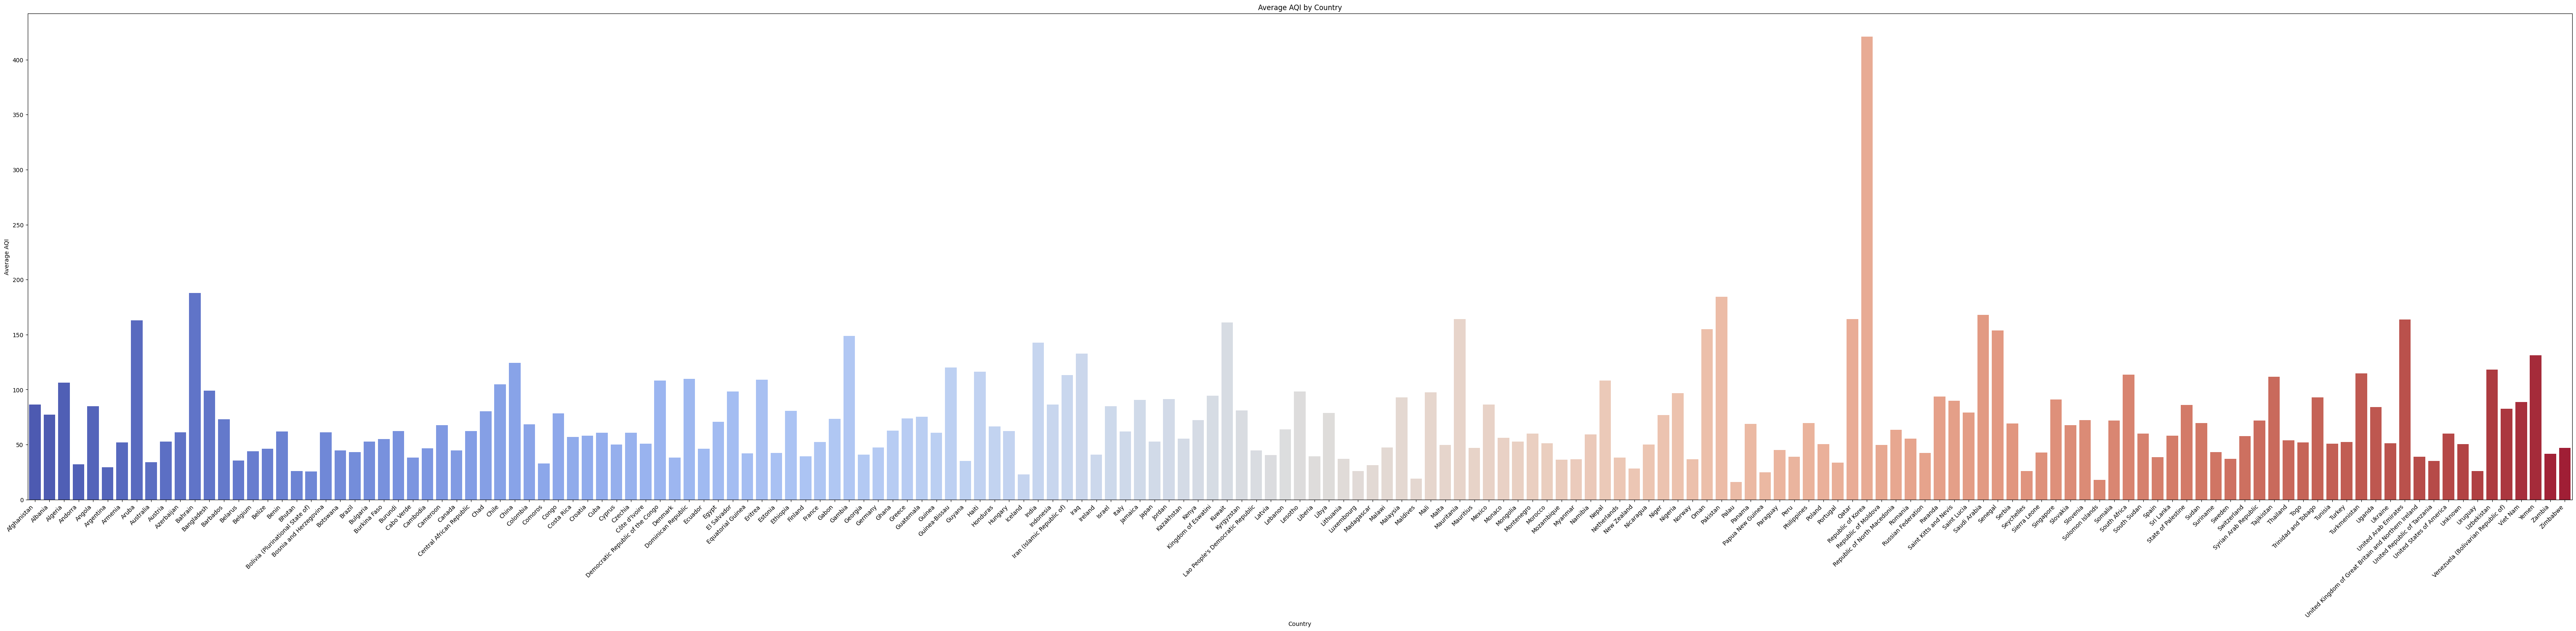

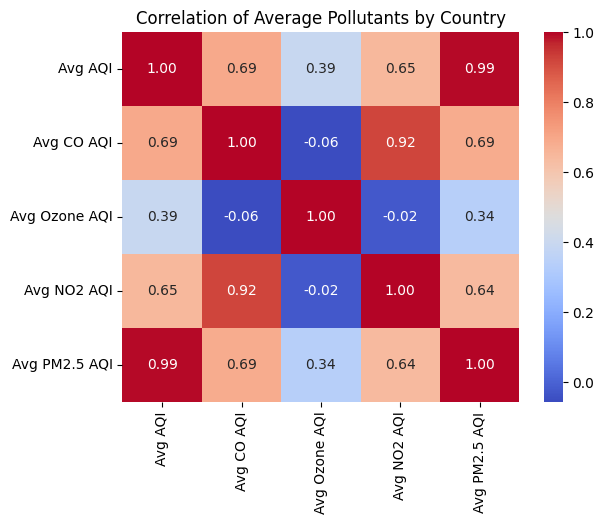

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'Data\Real-Data\AQI and Lat Long of Countries.csv'
data = pd.read_csv(file_path)

# Aggregate data at the country level
country_aggregates = data.groupby('Country').agg({
    'AQI Value': 'mean',
    'CO AQI Value': 'mean',
    'Ozone AQI Value': 'mean',
    'NO2 AQI Value': 'mean',
    'PM2.5 AQI Value': 'mean'
}).reset_index()

# Rename columns for clarity
country_aggregates.rename(columns={
    'AQI Value': 'Avg AQI',
    'CO AQI Value': 'Avg CO AQI',
    'Ozone AQI Value': 'Avg Ozone AQI',
    'NO2 AQI Value': 'Avg NO2 AQI',
    'PM2.5 AQI Value': 'Avg PM2.5 AQI'
}, inplace=True)



# Bar plot of average AQI by country
plt.figure(figsize=(78, 15))
sns.barplot(data=country_aggregates, x='Country', y='Avg AQI', palette='coolwarm')
plt.title('Average AQI by Country')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average AQI')
plt.show()

# Heatmap of pollutants correlation at the country level
country_pollutants = country_aggregates.drop(columns='Country')
sns.heatmap(country_pollutants.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Average Pollutants by Country')
plt.show()



